# Palm Club Employee Churn EDA Notebook

## Section 0 - Setup & Imports

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

REFERENCE_DATE = pd.Timestamp("2026-03-14")
HIGH_PERF_THRESHOLD = 75    # Will be adjusted after inspecting score distribution

## Section 1 - Data Loading & Inspection

In [67]:
emp = pd.read_csv("data/BOLT_Employees.csv")
applicant = pd.read_csv("data/BOLT_Applicants.csv")
changes = pd.read_csv("data/BOLT_EmployeeChanges.csv")
perf = pd.read_csv("data/BOLT_Performance.csv")
branch = pd.read_csv("data/BOLT_Branch.csv")

In [68]:
for name, df in {"emp": emp, "applicant": applicant, "changes": changes,
                  "perf": perf, "branch": branch}.items():
    print(f"\n=== {name} ===")
    print(df.shape)
    display(df.describe(include="all"))


=== emp ===
(1067, 9)


,EmployeeID,Wage,HiredOn,Branch#,Current status,Position,Role,AvgWorkingHours/Week,ApplicantID
count,1067.000000,1067,1067,1067.000000,1067,1067,1067,1067.000000,1067.000000
unique,NaN,3,796,NaN,3,2,6,NaN,NaN
top,NaN,Competitive,2025-05-29,NaN,Left,full-time,Server,NaN,NaN
freq,NaN,502,4,NaN,803,609,343,NaN,NaN
mean,5533.000000,NaN,NaN,3.991565,NaN,NaN,NaN,30.363261,105419.304592
std,308.160672,NaN,NaN,1.999279,NaN,NaN,NaN,10.256521,3021.678092
min,5000.000000,NaN,NaN,1.000000,NaN,NaN,NaN,12.100000,100001.000000
25%,5266.500000,NaN,NaN,2.000000,NaN,NaN,NaN,19.800000,102858.000000
50%,5533.000000,NaN,NaN,4.000000,NaN,NaN,NaN,33.700000,105377.000000
75%,5799.500000,NaN,NaN,6.000000,NaN,NaN,NaN,38.300000,107972.000000



=== applicant ===
(10500, 6)


,ApplicantID,PastRelevantExperience,YearsOfRelevantExperience,HighestEducationLevel,YearOfBirth,Hired
count,10500.000000,10500,10500.000000,10500,10500.000000,10500
unique,NaN,2,NaN,5,NaN,2
top,NaN,True,NaN,High School,NaN,False
freq,NaN,6546,NaN,4060,NaN,9433
mean,105249.500000,NaN,1.660762,NaN,2001.468667,NaN
std,3031.233247,NaN,1.956612,NaN,4.421487,NaN
min,100000.000000,NaN,0.000000,NaN,1978.000000,NaN
25%,102624.750000,NaN,0.000000,NaN,1999.000000,NaN
50%,105249.500000,NaN,1.000000,NaN,2002.000000,NaN
75%,107874.250000,NaN,3.000000,NaN,2005.000000,NaN



=== changes ===
(1165, 4)


,EmployeeID,New Role,DateChanged,ReasonForLeaving
count,1165.000000,1165,1165,942
unique,NaN,7,832,9
top,NaN,Quit,2025-02-01,Better Offer
freq,NaN,803,5,231
mean,5544.229185,NaN,NaN,NaN
std,309.531752,NaN,NaN,NaN
min,5000.000000,NaN,NaN,NaN
25%,5271.000000,NaN,NaN,NaN
50%,5552.000000,NaN,NaN,NaN
75%,5816.000000,NaN,NaN,NaN



=== perf ===
(2189, 3)


,EmployeeID,DateReviewed,PerformanceScore
count,2189.000000,2189,2189.000000
unique,NaN,1242,NaN
top,NaN,2025-08-08,NaN
freq,NaN,6,NaN
mean,5543.920968,NaN,81.362878
std,309.288407,NaN,8.986163
min,5000.000000,NaN,58.030000
25%,5271.000000,NaN,74.980000
50%,5551.000000,NaN,81.500000
75%,5815.000000,NaN,88.110000



=== branch ===
(1049, 7)


,BranchNo,BranchName,Latitude,Longitude,ReviewText,Stars,DatePosted
count,1049.000000,1049,1049.000000,1049.000000,1049,1049.000000,1049
unique,NaN,7,NaN,NaN,35,NaN,797
top,NaN,SFU,NaN,NaN,Always a pleasant experience.,NaN,2025-12-22
freq,NaN,150,NaN,NaN,58,NaN,4
mean,4.002860,NaN,49.235748,-123.053173,NaN,3.882745,NaN
std,1.999759,NaN,0.040562,0.126739,NaN,1.200579,NaN
min,1.000000,NaN,49.166600,-123.246000,NaN,1.000000,NaN
25%,2.000000,NaN,49.191300,-123.133600,NaN,3.000000,NaN
50%,4.000000,NaN,49.243500,-123.101200,NaN,4.000000,NaN
75%,6.000000,NaN,49.278100,-122.919900,NaN,5.000000,NaN


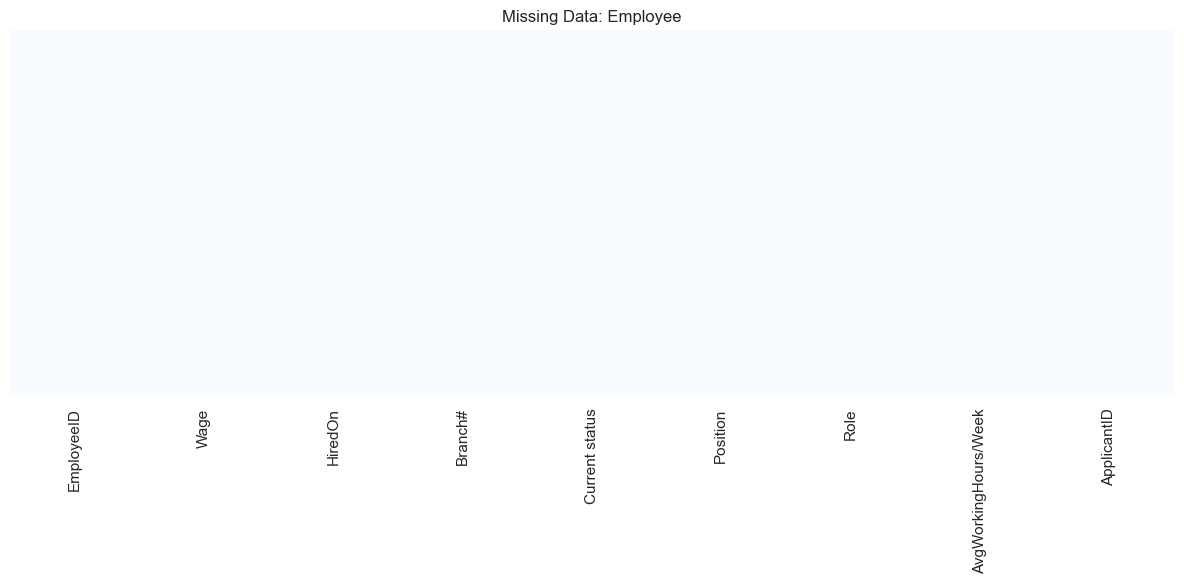

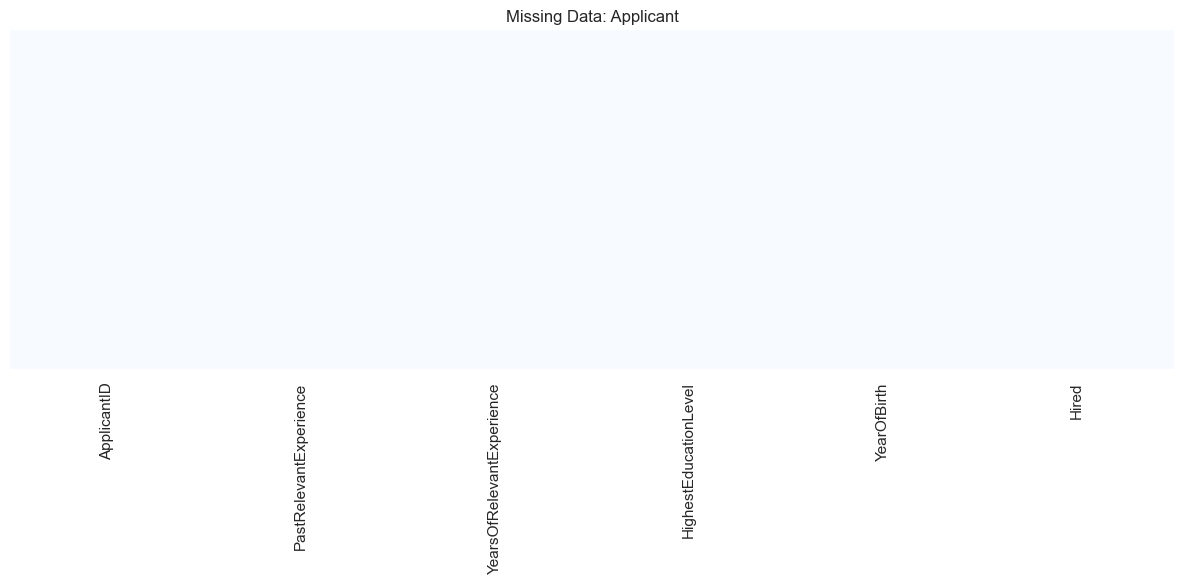

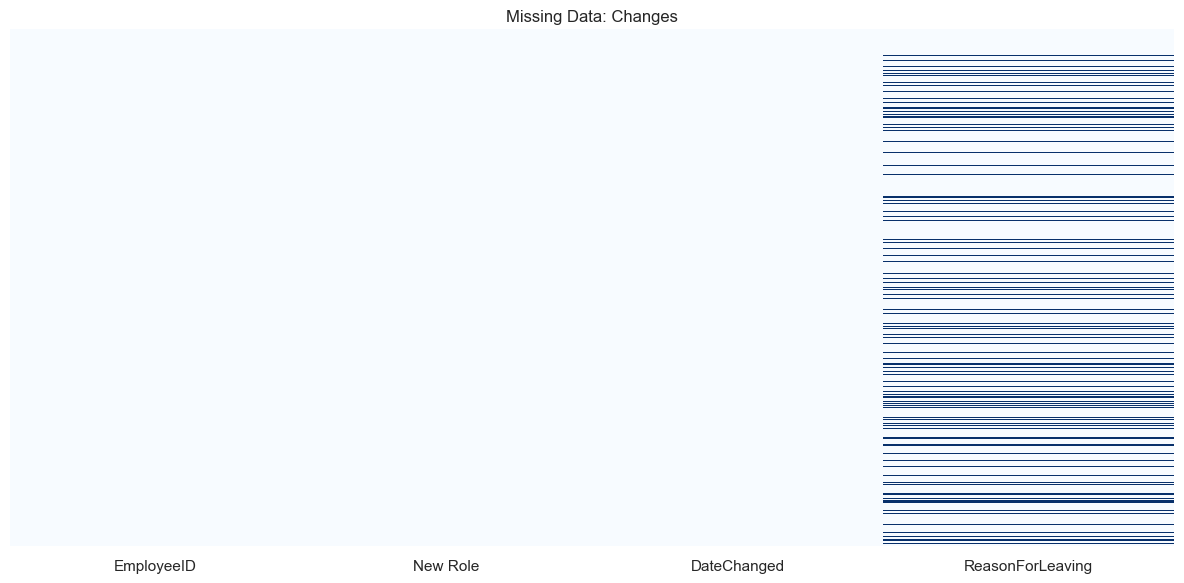

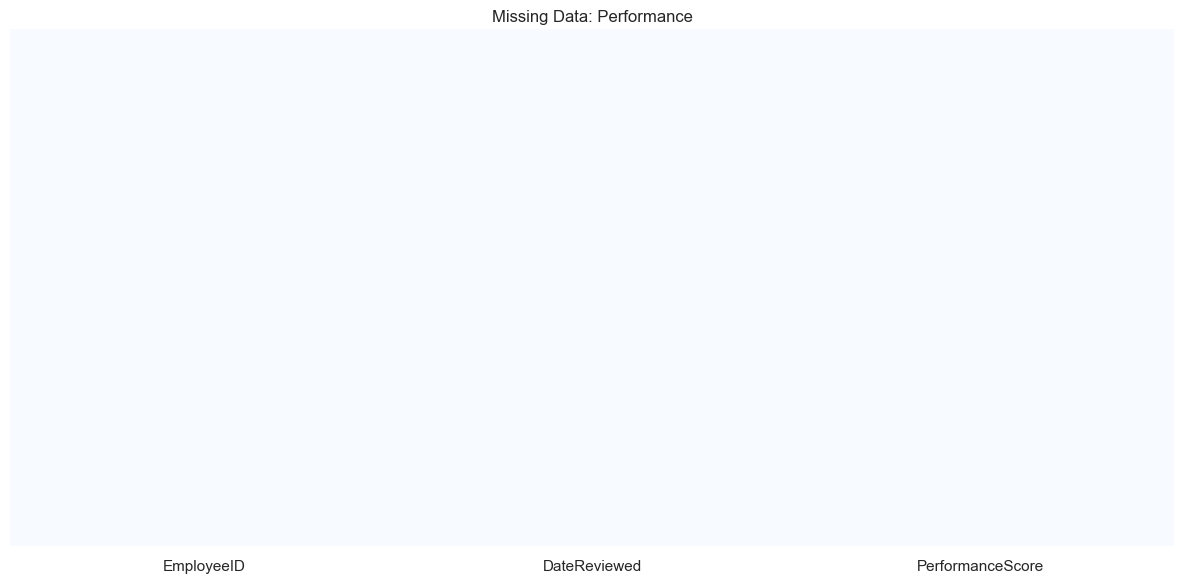

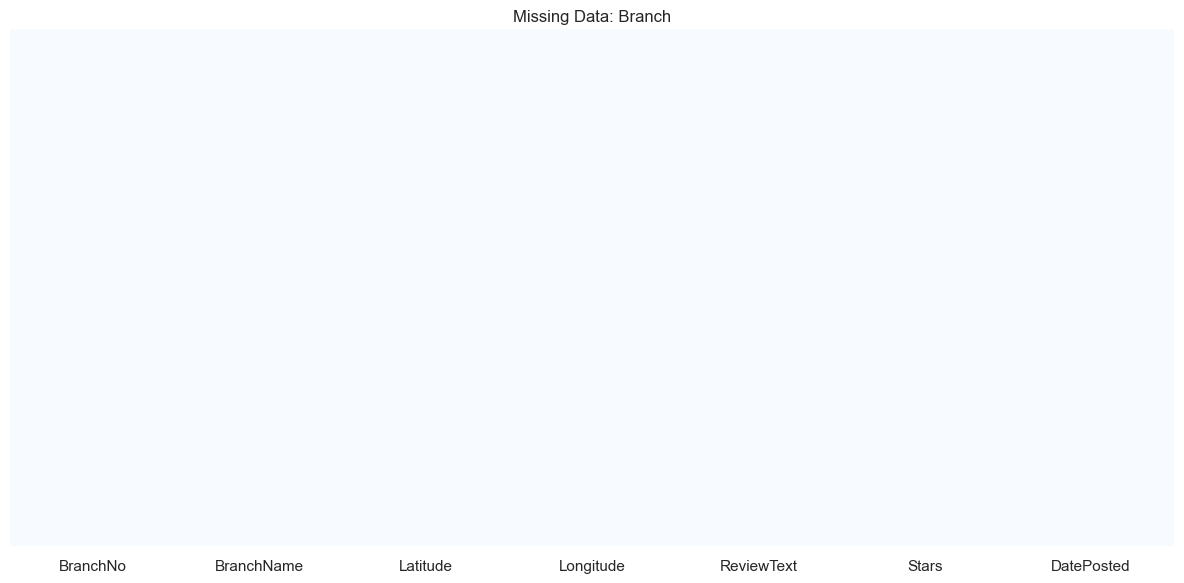

In [69]:
# Missing data heatmaps
for name, df in {
    "Employee": emp,
    "Applicant": applicant,
    "Changes": changes,
    "Performance": perf,
    "Branch": branch,
}.items():
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="Blues")
    plt.title(f"Missing Data: {name}")
    plt.tight_layout()
    plt.show()

## Section 2 - Data Cleaning

In [70]:
# Parse dates
emp["HiredOn"] = pd.to_datetime(emp["HiredOn"])
changes["DateChanged"] = pd.to_datetime(changes["DateChanged"])
perf["DateReviewed"] = pd.to_datetime(perf["DateReviewed"])
branch["DatePosted"] = pd.to_datetime(branch["DatePosted"])

### (A) Derive Tenure (days employed)

In [71]:
print(changes["New Role"].unique())

['Quit' 'Dismissed' 'Bartender' 'Server' 'Manager' 'Server Assistant'
 'Shift Lead']


In [72]:

# For active employees, tenure runs to today
# For exited employees, tenure runs to their exit date

exit_dates = (
    changes[changes["New Role"].isin(["Quit", "Dismissed"])]
    .groupby("EmployeeID")["DateChanged"].max()
    .rename("ExitDate")
)

employee = emp.merge(exit_dates, on="EmployeeID", how="left")
employee["EndDate"] = employee["ExitDate"].fillna(REFERENCE_DATE)
employee["TenureDays"] = (employee["EndDate"] - employee["HiredOn"]).dt.days
employee["TenureMonths"] = employee["TenureDays"] / 30.44

print(employee.head())

   EmployeeID         Wage    HiredOn  Branch# Current status   Position  \
0        5764      Minimum 2022-06-13        1        Working  full-time   
1        5997      Minimum 2024-02-26        1        Working  full-time   
2        5454  Competitive 2024-06-20        1        Working  full-time   
3        5557  Competitive 2024-09-04        1        Working  full-time   
4        5923      Minimum 2024-12-07        1        Working  full-time   

      Role  AvgWorkingHours/Week  ApplicantID ExitDate    EndDate  TenureDays  \
0  Manager                  48.8       107642      NaT 2026-03-14        1370   
1  Manager                  50.4       109966      NaT 2026-03-14         747   
2  Manager                  49.2       104693      NaT 2026-03-14         632   
3  Manager                  52.0       105628      NaT 2026-03-14         556   
4  Manager                  48.6       109352      NaT 2026-03-14         462   

   TenureMonths  
0     45.006570  
1     24.540079  
2 

### (B) Identify Exits vs. Promotions

In [73]:
changes["New Role"].value_counts()

New Role
Quit                803
Dismissed           139
Bartender           117
Server               36
Manager              34
Shift Lead           31
Server Assistant      5
Name: count, dtype: int64

In [74]:
EXIT_LABELS = ["Quit", "Dismissed"]
PROMOTION_LABELS = ["Bartender", "Server", "Manager", "Shift Lead", "Server Assistant"]

changes["isExit"] = changes["New Role"].isin(EXIT_LABELS)
changes["isPromotion"] = changes["New Role"].isin(PROMOTION_LABELS)


### (C) Merge Average Performance onto Employee Table

In [75]:
avg_perf = (
    perf.groupby("EmployeeID")["PerformanceScore"]
    .mean()
    .round(2)
    .rename("AvgPerfScore")
    .reset_index()
)

employee = employee.merge(avg_perf, on="EmployeeID", how="left")
employee["AvgPerfScore"].describe()

count    1067.000000
mean       79.205820
std         8.494022
min        58.070000
25%        73.590000
50%        79.320000
75%        85.445000
max        98.200000
Name: AvgPerfScore, dtype: float64

### (D) Flag Churned Employees

In [76]:
employee["Churned"] = emp["Current status"].isin(["Left", "Fired"]).astype(int)


In [77]:
employee["Churned"].value_counts()

Churned
1    942
0    125
Name: count, dtype: int64

### (E) Merge Applicant Data

In [78]:
employee = employee.merge(
    applicant[["ApplicantID", "YearOfBirth", "HighestEducationLevel", 
               "YearsOfRelevantExperience", "PastRelevantExperience"]],
    on="ApplicantID", how="left"
)
employee["AgeAtHire"] = employee["HiredOn"].dt.year - employee["YearOfBirth"]

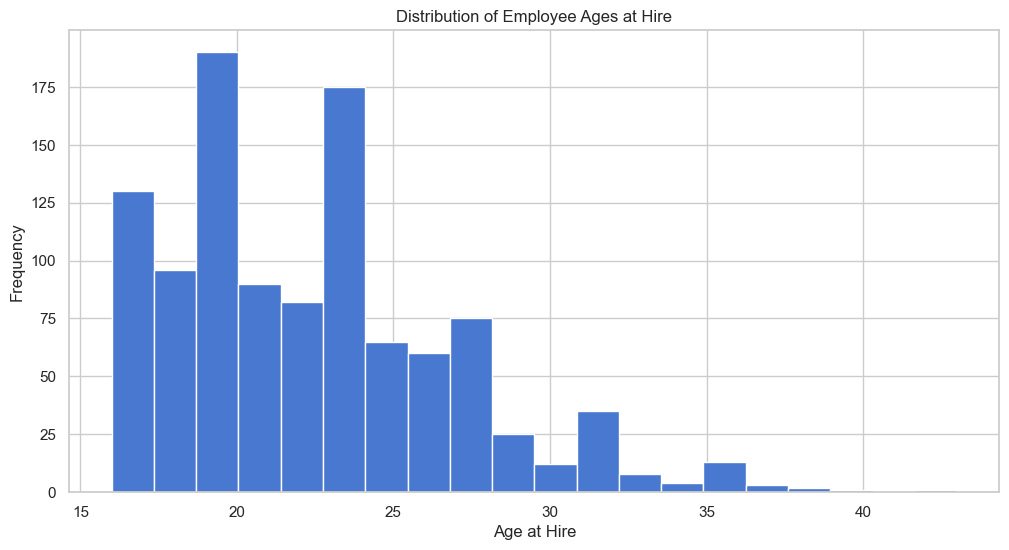

In [79]:

plt.hist(employee["AgeAtHire"], bins=20)
plt.xlabel("Age at Hire")
plt.ylabel("Frequency")
plt.title("Distribution of Employee Ages at Hire")
plt.show()

In [80]:
# Compute first promotion date per employee from the changes table
first_promo = (
    changes[changes["isPromotion"]]
    .sort_values("DateChanged")
    .groupby("EmployeeID")
    .first()
    .reset_index()[["EmployeeID", "DateChanged"]]
    .rename(columns={"DateChanged": "FirstPromoDate"})
)

# Merge onto employee and derive MonthsToPromotion
employee = employee.merge(first_promo, on="EmployeeID", how="left")
employee["FirstPromoDate"]= pd.to_datetime(employee["FirstPromoDate"])
employee["EverPromoted"] = employee["FirstPromoDate"].notna().astype(int)
employee["MonthsToPromotion"]  = (
    (employee["FirstPromoDate"] - employee["HiredOn"]).dt.days / 30.44
)

# Verify
print(f"Ever promoted:      {employee['EverPromoted'].sum()} employees")
print(f"Never promoted:     {(employee['EverPromoted'] == 0).sum()} employees")
print(f"MonthsToPromotion range: {employee['MonthsToPromotion'].min():.1f} – {employee['MonthsToPromotion'].max():.1f}")
print(employee[["EmployeeID", "EverPromoted", "MonthsToPromotion"]].head(10))

employee.to_csv("employee_master.csv", index=False)


Ever promoted:      178 employees
Never promoted:     889 employees
MonthsToPromotion range: 0.0 – 15.8
   EmployeeID  EverPromoted  MonthsToPromotion
0        5764             1           9.034166
1        5997             1          10.939553
2        5454             1           6.176084
3        5557             1           4.664915
4        5923             0                NaN
5        5572             1           2.036794
6        5155             0                NaN
7        5711             0                NaN
8        5669             0                NaN
9        5099             0                NaN


## Section 3 - Defining "High Performer"
- Answers: How is “high-performing” defined in the data? (Guiding Q1)

### (A) Score Distribution

In [81]:
# Histogram of all average performance scores 
# employee["AvgPerfScore"].hist(bins=30, color="steelblue", edgecolor="white")
# plt.axvline(HIGH_PERF_THRESHOLD, color="red", linestyle="--", label=f"Threshold = {HIGH_PERF_THRESHOLD}")
# plt.title("Distribution of Average Performance Scores")
# plt.xlabel("Avg Performance Score")
# plt.ylabel("Employee Count")
# plt.legend()

In [82]:
# plt.boxplot(employee["AvgPerfScore"], vert=False)
# plt.axvline(HIGH_PERF_THRESHOLD, color="red", linestyle="--", label=f"Threshold = {HIGH_PERF_THRESHOLD}")
# plt.title("Distribution of Average Performance Scores")
# plt.xlabel("Avg Performance Score")
# plt.legend()

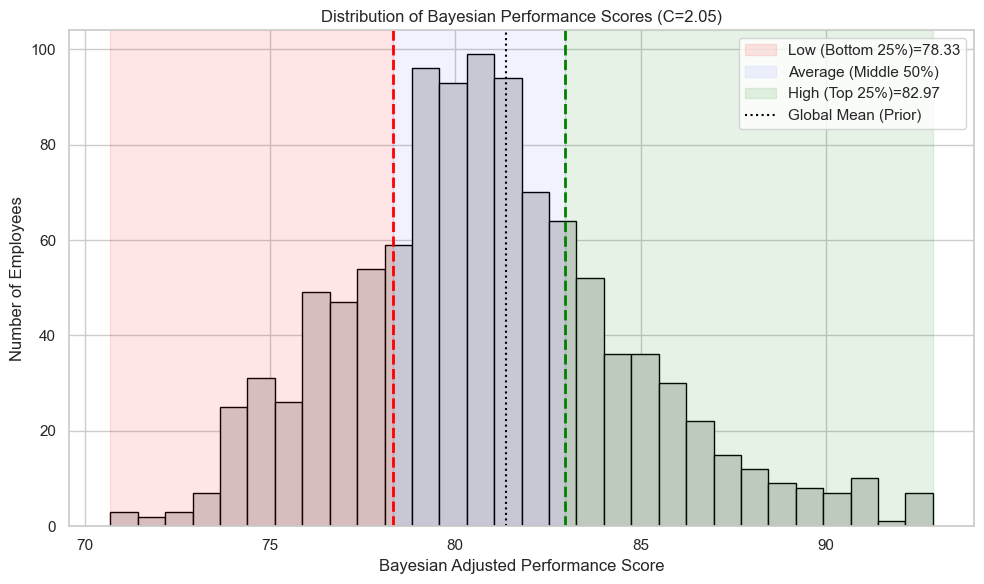

,EmployeeID,SimpleMean,ReviewCount,BayesianScore,PerformanceCategory
0,5000,78.300,1,80.359165,Average
1,5001,78.110,1,80.296901,Average
2,5002,95.750,1,86.077577,High
3,5003,89.894,5,87.411992,High
4,5004,89.210,1,83.934401,High


In [83]:
global_mean = perf['PerformanceScore'].mean()
reviews_per_employee = perf.groupby('EmployeeID').size()
C = reviews_per_employee.mean() # Your confidence constant = average number of reviews per employee

# 2. Calculate per-employee stats
employee_stats = perf.groupby('EmployeeID')['PerformanceScore'].agg(['mean', 'count']).reset_index()
employee_stats.columns = ['EmployeeID', 'SimpleMean', 'ReviewCount']

# 3. Apply Bayesian Average Formula
# Formula: (v*R + C*m) / (v + C)
def bayesian_avg(row):
    v = row['ReviewCount']
    R = row['SimpleMean']
    return (v * R + C * global_mean) / (v + C)

employee_stats['BayesianScore'] = employee_stats.apply(bayesian_avg, axis=1)

# 4. Calculate Thresholds based on Bayesian Scores
# Using your Q1/Q3 logic for Top 25%, Mid 50%, Bottom 25%
q1 = employee_stats['BayesianScore'].quantile(0.25)
q3 = employee_stats['BayesianScore'].quantile(0.75)

# 5. Categorize
conditions = [
    employee_stats['BayesianScore'] >= q3,
    employee_stats['BayesianScore'] < q1
]
choices = ['High', 'Low']
employee_stats['PerformanceCategory'] = np.select(conditions, choices, default='Average')

# 6. Plotting the Adjusted Distribution
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(employee_stats['BayesianScore'], bins=30, color='lightgray', edgecolor='black')

# Shade regions
plt.axvspan(employee_stats['BayesianScore'].min(), q1, color='red', alpha=0.1, label=f'Low (Bottom 25%)={q1:.2f}')
plt.axvspan(q1, q3, color='blue', alpha=0.05, label=f'Average (Middle 50%)')
plt.axvspan(q3, employee_stats['BayesianScore'].max(), color='green', alpha=0.1, label=f'High (Top 25%)={q3:.2f}')

# Vertical lines for the "Confidence Bar"
plt.axvline(q1, color='red', linestyle='dashed', linewidth=2)
plt.axvline(q3, color='green', linestyle='dashed', linewidth=2)
plt.axvline(global_mean, color='black', linestyle=':', label='Global Mean (Prior)')

plt.xlabel('Bayesian Adjusted Performance Score')
plt.ylabel('Number of Employees')
plt.title(f'Distribution of Bayesian Performance Scores (C={C:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

employee_stats.head()

### (B) Define New "High Performer" Flag

In [84]:
# --- HIGH PERFORMER THRESHOLD DECISION ---
# The cutoff now uses the Bayesian-adjusted performance score rather than the raw average score.
# This keeps the threshold data-driven while shrinking extreme values toward the global mean
# for employees with fewer reviews. The top quartile (Q3) remains the high-performer definition.

# Merge Bayesian scores onto the employee table and use them for the high-performer cutoff
employee = employee.drop(columns=['BayesianScore'], errors='ignore').merge(
    employee_stats[['EmployeeID', 'BayesianScore']], on='EmployeeID', how='left'
)

HIGH_PERF_THRESHOLD = employee_stats['BayesianScore'].quantile(0.75)
print(f"High performer threshold (Bayesian Q3): {HIGH_PERF_THRESHOLD:.2f}")

employee['IsHighPerformer'] = (employee['BayesianScore'] >= HIGH_PERF_THRESHOLD).astype(int)
print(f"\nHigh performers: {employee['IsHighPerformer'].sum()} employees "
      f"({employee['IsHighPerformer'].mean():.2%} of workforce)")


High performer threshold (Bayesian Q3): 82.97

High performers: 268 employees (25.12% of workforce)


## Section 4 - Churn Rate Overview 
- Answers: What is the turnover rate of high performers compared to others? (Guiding Q1)

### (A) Overall Churn Rate by Performance Group

In [85]:
churn_summary = (
    employee.groupby("IsHighPerformer")["Churned"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "ChurnRate", "count": "HeadCount"})
)
churn_summary["ChurnRate"] = churn_summary["ChurnRate"].map("{:.2%}".format)
print(churn_summary)

                ChurnRate  HeadCount
IsHighPerformer                     
0                  87.36%        799
1                  91.04%        268


### (B) Countplot: Churn by Performance Tier (High vs. Others)

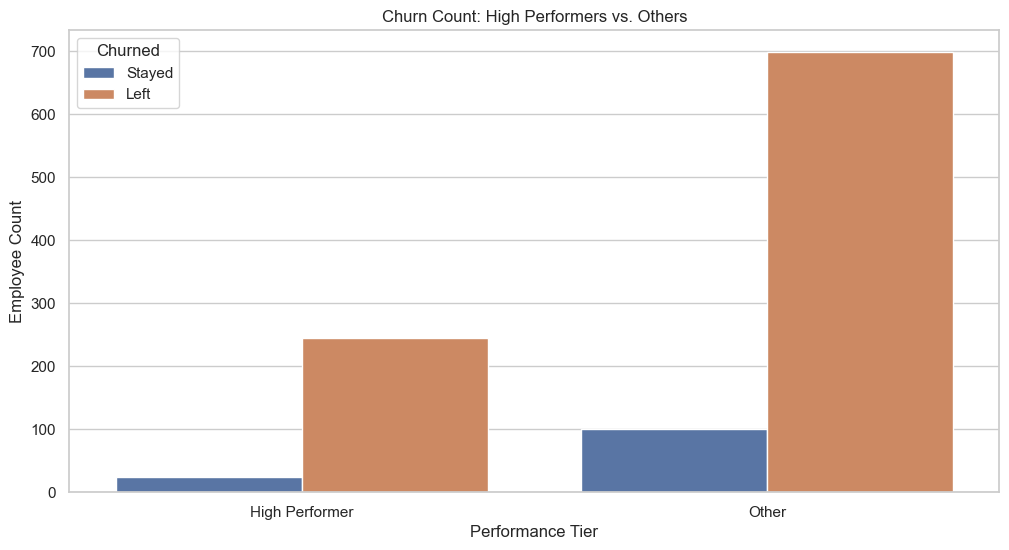

In [86]:
employee["PerfTier"] = employee["IsHighPerformer"].map({1: "High Performer", 0: "Other"})

sns.countplot(x="PerfTier", hue="Churned", data=employee,
              palette=["#4C72B0", "#DD8452"])
plt.title("Churn Count: High Performers vs. Others")
plt.xlabel("Performance Tier")
plt.ylabel("Employee Count")
plt.legend(title="Churned", labels=["Stayed", "Left"])

### (C) Churn Rate by Role

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Bartender'),
  Text(1, 0, 'Host'),
  Text(2, 0, 'Manager'),
  Text(3, 0, 'Server'),
  Text(4, 0, 'Server Assistant'),
  Text(5, 0, 'Shift Lead')])

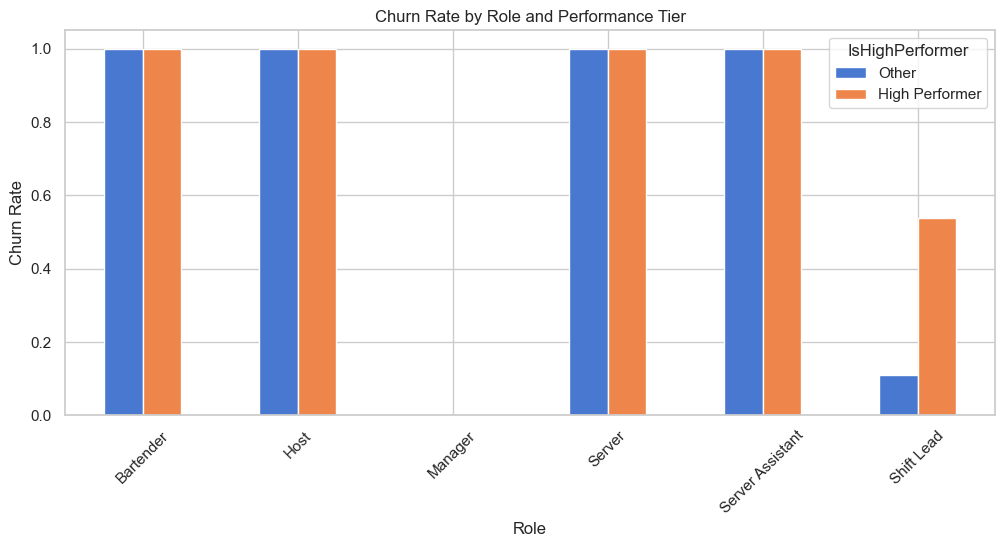

In [87]:
role_churn = (
    employee.groupby(["Role", "IsHighPerformer"])["Churned"]
    .mean()
    .unstack()
    .rename(columns={0: "Other", 1: "High Performer"})
)
role_churn.plot(kind="bar", figsize=(12, 5))
plt.title("Churn Rate by Role and Performance Tier")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)

In [88]:
# Check how many employees are being flagged as churned
print(f"Churned employees: {employee['Churned'].sum()} / {len(employee)}")

# Spot-check: look at a few flagged employees' full change history
sample_churned = employee[employee["Churned"] == 1]["EmployeeID"].head(3)
changes[changes["EmployeeID"].isin(sample_churned)].sort_values(["EmployeeID", "DateChanged"])

Churned employees: 942 / 1067


,EmployeeID,New Role,DateChanged,ReasonForLeaving,isExit,isPromotion
213,5203,Bartender,2022-07-22,NaN,False,True
214,5203,Shift Lead,2023-09-20,NaN,False,True
215,5203,Quit,2024-07-29,Lack of Growth,True,False
1048,5967,Bartender,2023-12-04,NaN,False,True
1049,5967,Shift Lead,2024-07-16,NaN,False,True
1050,5967,Quit,2025-07-09,Poor Management,True,False
1079,5991,Shift Lead,2022-10-08,NaN,False,True
1080,5991,Quit,2023-09-30,Poor Management,True,False


### (D) Check whether position adds information beyond the role 

In [89]:
employee.groupby(["Role", "Position"]).size().unstack(fill_value=0)

Position,full-time,part-time
Role,,
Bartender,98,49
Host,49,49
Manager,49,0
Server,196,147
Server Assistant,168,164
Shift Lead,49,49


## Section 5 - Tenure at Exit Analysis
- Answers: At what point in tenure are high-performing employees most likely to exit? (e.g., early tenure vs. after extended time in role) (Guiding Q2)

In [90]:
# Only include employees who actually left — exclude currently Working staff
exited = employee[employee["Churned"] == 1].copy()
hp_exited = exited[exited["IsHighPerformer"] == 1]
oth_exited = exited[exited["IsHighPerformer"] == 0]

### (A) Kernel Density Estimate at Exit by Performance Tier

/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/2253807066.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(hp_exited["TenureMonths"],  label="High Performers who left",
/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/2253807066.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(oth_exited["TenureMonths"], label="Others who left",


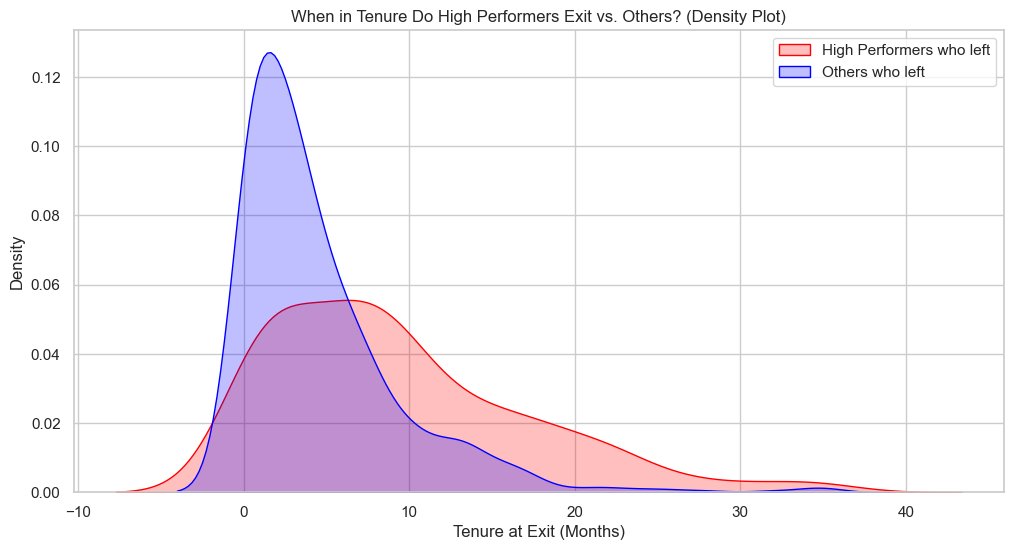

In [91]:
plt.figure(figsize=(12, 6))
sns.kdeplot(hp_exited["TenureMonths"],  label="High Performers who left",
            shade=True, color="red")
sns.kdeplot(oth_exited["TenureMonths"], label="Others who left",
            shade=True, color="blue")
plt.xlabel("Tenure at Exit (Months)")
plt.title("When in Tenure Do High Performers Exit vs. Others? (Density Plot)")
plt.legend()

### (B) Tenure Buckets: Exit Volume 

/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/2642079979.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exited.groupby(["TenureBucket", "IsHighPerformer"]).size().unstack().rename(


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '0–6 mo'),
  Text(1, 0, '6–12 mo'),
  Text(2, 0, '1–2 yr'),
  Text(3, 0, '2–4 yr'),
  Text(4, 0, '4+ yr')])

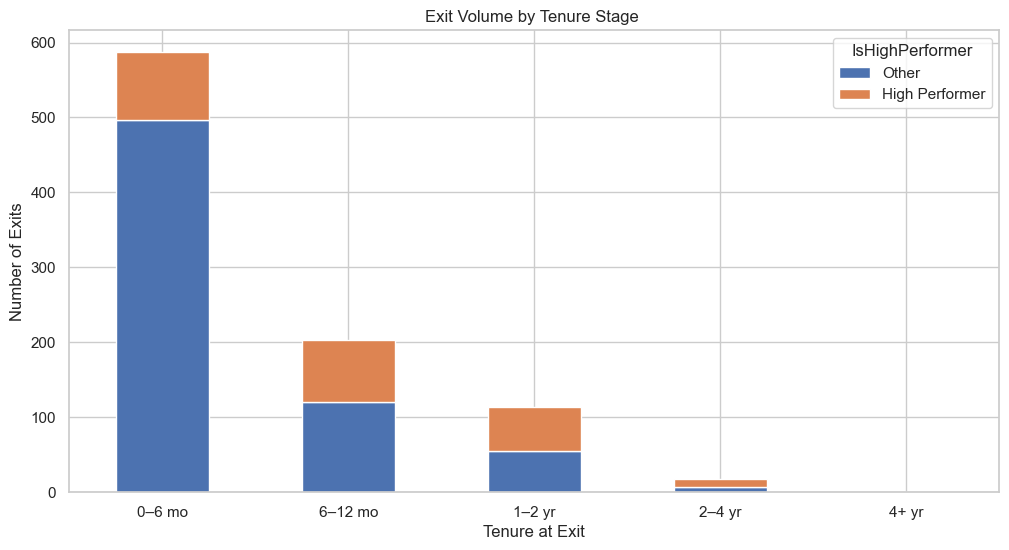

In [92]:
bins   = [0, 6, 12, 24, 48, 9999]
labels = ["0–6 mo", "6–12 mo", "1–2 yr", "2–4 yr", "4+ yr"]
exited["TenureBucket"] = pd.cut(exited["TenureMonths"], bins=bins, labels=labels)

exited.groupby(["TenureBucket", "IsHighPerformer"]).size().unstack().rename(
    columns={0: "Other", 1: "High Performer"}
).plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"], edgecolor="white")
plt.title("Exit Volume by Tenure Stage ")
plt.xlabel("Tenure at Exit")
plt.ylabel("Number of Exits")
plt.xticks(rotation=0)


## Section 6 - Time-in-Role Before Promotion

Answers: 
- Does time-in-role before promotion increase the likelihood of exit
among strong performers? (Guiding Q3)
- Are high performers promoted faster than average performers - and if
not, why? (Guiding Q4)

In [93]:


promoted_to = (
    changes[changes["isPromotion"]]
    .sort_values("DateChanged")
    .groupby("EmployeeID")["New Role"]
    .first()
    .rename("PromotedTo")
    .reset_index()
)

promo_df = employee.merge(promoted_to, on="EmployeeID", how="left")

# Verify — these columns must already exist from Cell 23
assert "MonthsToPromotion" in promo_df.columns
assert "EverPromoted"      in promo_df.columns
assert "FirstPromoDate"    in promo_df.columns

print(f"promo_df rows: {len(promo_df)}")
print(f"Ever promoted: {promo_df['EverPromoted'].sum()}")
print(promo_df[["EmployeeID", "EverPromoted", "MonthsToPromotion", "PromotedTo"]].head(5))

promo_df rows: 1067
Ever promoted: 178
   EmployeeID  EverPromoted  MonthsToPromotion        PromotedTo
0        5764             1           9.034166  Server Assistant
1        5997             1          10.939553           Manager
2        5454             1           6.176084           Manager
3        5557             1           4.664915           Manager
4        5923             0                NaN               NaN


### (A) Kernel Density Estimate: Months to First Promotion, High vs. Other (Q4)

/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/2140119716.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(promoted_hp["MonthsToPromotion"],  label="High Performers",
/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/2140119716.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(promoted_oth["MonthsToPromotion"], label="Others",


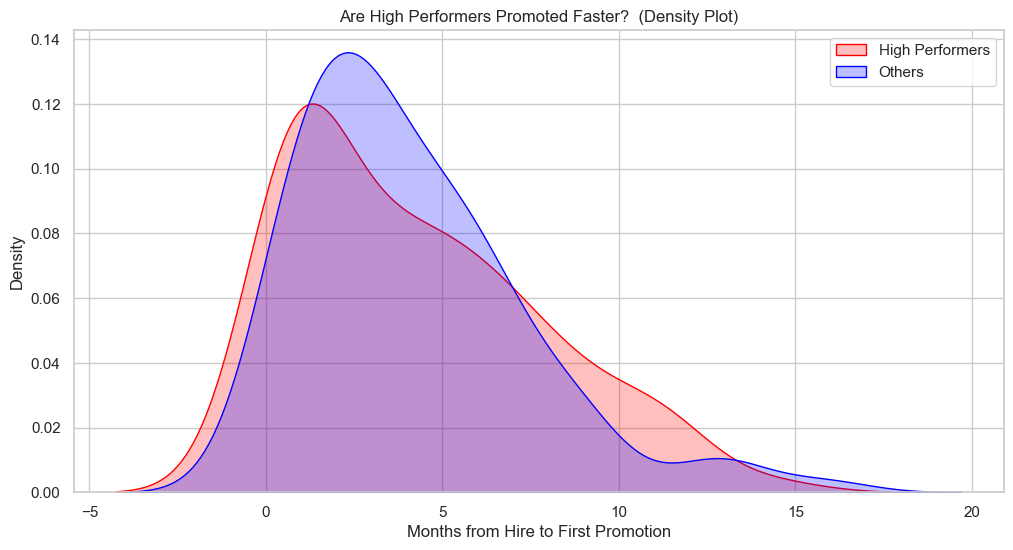

In [94]:
promoted_hp  = promo_df[(promo_df["EverPromoted"] == 1) & (promo_df["IsHighPerformer"] == 1)]
promoted_oth = promo_df[(promo_df["EverPromoted"] == 1) & (promo_df["IsHighPerformer"] == 0)]

plt.figure(figsize=(12, 6))
sns.kdeplot(promoted_hp["MonthsToPromotion"],  label="High Performers",
            shade=True, color="red")
sns.kdeplot(promoted_oth["MonthsToPromotion"], label="Others",
            shade=True, color="blue")
plt.xlabel("Months from Hire to First Promotion")
plt.title("Are High Performers Promoted Faster?  (Density Plot)")
plt.legend()

### (B) Tenure at Exit for Never-Promoted High Performers (Q3)

Text(0, 0.5, 'Count')

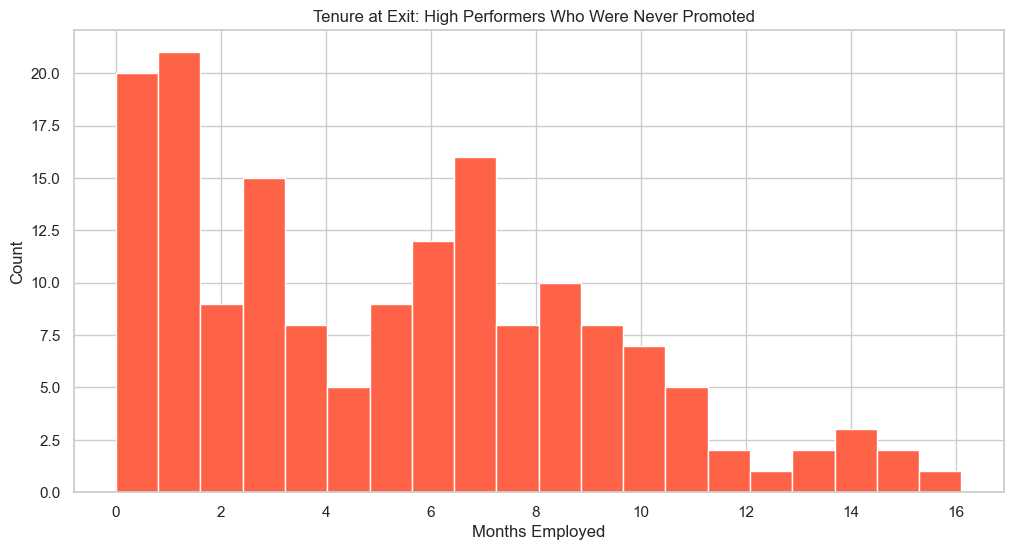

In [95]:
hp_no_promo_exited = promo_df[
    (promo_df["IsHighPerformer"] == 1) &
    (promo_df["EverPromoted"] == 0) &
    (promo_df["Churned"] == 1)
]

hp_no_promo_exited["TenureMonths"].hist(bins=20, color="tomato", edgecolor="white")
plt.title("Tenure at Exit: High Performers Who Were Never Promoted  ")
plt.xlabel("Months Employed")
plt.ylabel("Count")

### (C) Median Months to Promotion: Summary Table

In [96]:
summary = (
    promo_df[promo_df["EverPromoted"] == 1]
    .groupby("IsHighPerformer")["MonthsToPromotion"]
    .agg(["median", "mean", "count"])
)
summary.index = summary.index.map({0: "Other", 1: "High Performer"})
print(summary.round(1))

                 median  mean  count
IsHighPerformer                     
Other               3.4   4.1     89
High Performer      3.6   4.2     89


## Section 7 - Does promotion affect retention rate?

Answers: Do employees who receive promotions show significantly higher
retention than those who do not? (Guiding Q5)

EverPromoted
Never Promoted    91.6%
Promoted          89.9%
Name: Churned, dtype: object


([<matplotlib.axis.XTick at 0x12154cb90>,
 [Text(0, 0, 'Never Promoted'), Text(1, 0, 'Promoted')])

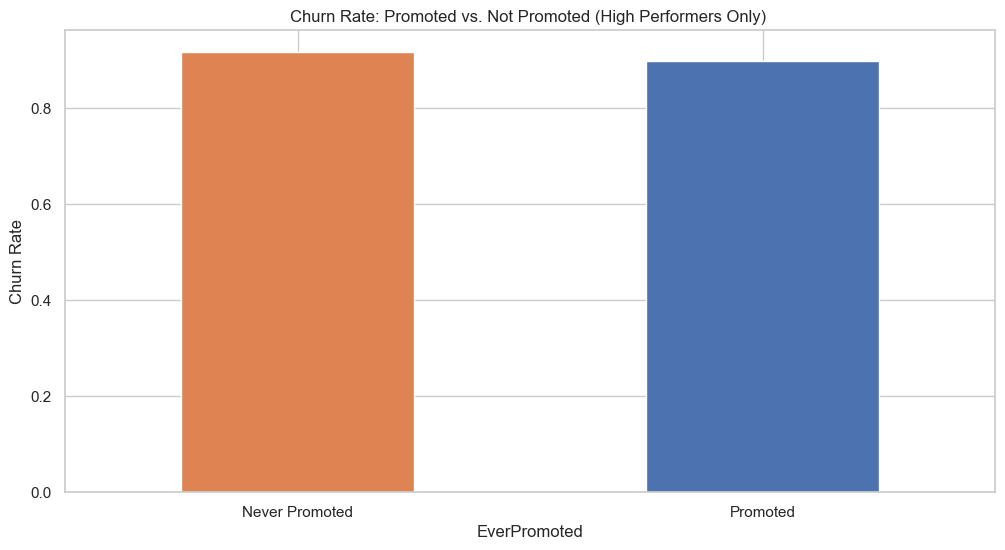

In [97]:
hp = promo_df[promo_df["IsHighPerformer"] == 1].copy()

retention = (
    hp.groupby("EverPromoted")["Churned"]
    .mean()
    .rename({0: "Never Promoted", 1: "Promoted"})
)
print(retention.map("{:.1%}".format))

retention.plot(kind="bar", color=["#DD8452", "#4C72B0"], edgecolor="white")
plt.title("Churn Rate: Promoted vs. Not Promoted (High Performers Only) ")
plt.ylabel("Churn Rate")
plt.xticks([0, 1], ["Never Promoted", "Promoted"], rotation=0)

In [98]:
# Check what's actually in promo_df
print(promo_df["Churned"].value_counts())
print(f"Churn rate in promo_df: {promo_df['Churned'].mean():.1%}")

# Compare to your clean employee table
print(f"Churn rate in employee: {employee['Churned'].mean():.1%}")

Churned
1    942
0    125
Name: count, dtype: int64
Churn rate in promo_df: 88.3%
Churn rate in employee: 88.3%


The more useful question for Q5 isn't churn rate — it's survival time. Even if promoted employees still eventually leave at nearly the same rate, they may stay significantly longer before doing so. Investigating this:


/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/2536227935.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(hp_promo["TenureMonths"],    label="Promoted",        shade=True, color="blue")
/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/2536227935.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(hp_no_promo["TenureMonths"], label="Never Promoted",  shade=True, color="red")


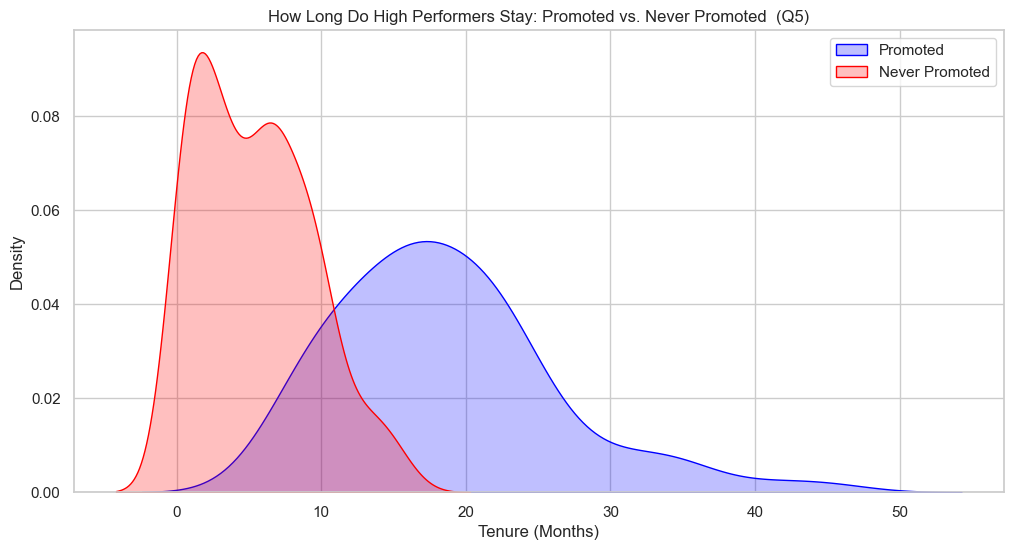

In [99]:
hp = promo_df[promo_df["IsHighPerformer"] == 1].copy()

# Compare tenure distribution: promoted vs. never promoted
hp_promo     = hp[hp["EverPromoted"] == 1]
hp_no_promo  = hp[hp["EverPromoted"] == 0]

plt.figure(figsize=(12, 6))
sns.kdeplot(hp_promo["TenureMonths"],    label="Promoted",        shade=True, color="blue")
sns.kdeplot(hp_no_promo["TenureMonths"], label="Never Promoted",  shade=True, color="red")
plt.xlabel("Tenure (Months)")
plt.title("How Long Do High Performers Stay: Promoted vs. Never Promoted  (Q5)")
plt.legend()


In [100]:
# Summary table — median tenure is the key number
print(hp.groupby("EverPromoted")["TenureMonths"].agg(["median", "mean", "count"]).round(1))

              median  mean  count
EverPromoted                     
0                5.0   5.4    179
1               17.7  18.5     89


## Section 8 - Branch Level Churn Differences
Answers: Are there branch-level differences in turnover of high performers? (e.g.,
certain managers or locations with consistently higher exit rates) (Guiding Q6)

In [101]:
# Rename branch join key to match emp before merging
branch_renamed = branch.rename(columns={"BranchNo": "Branch#"})

branch_churn = (
    employee[employee["IsHighPerformer"] == 1]
    .groupby("Branch#")["Churned"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "HPChurnRate", "count": "HPCount"})
    .sort_values("HPChurnRate", ascending=False)
)
print(branch_churn)

         HPChurnRate  HPCount
Branch#                      
3           1.000000       35
6           1.000000       33
2           0.947368       38
4           0.928571       42
7           0.863636       44
5           0.860465       43
1           0.787879       33


### (A) High Performer Churn Rate By Branch

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '3'),
  Text(1, 0, '6'),
  Text(2, 0, '2'),
  Text(3, 0, '4'),
  Text(4, 0, '7'),
  Text(5, 0, '5'),
  Text(6, 0, '1')])

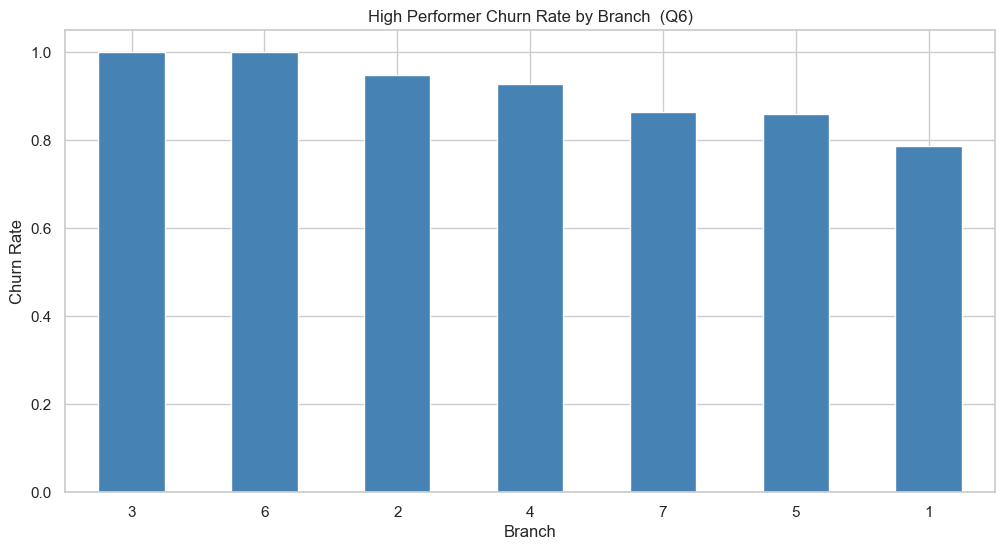

In [102]:
branch_churn["HPChurnRate"].plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("High Performer Churn Rate by Branch  (Q6)")
plt.xlabel("Branch")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)

### (B) Branch Churn vs. Customer Star Rating 


In [103]:
avg_stars = branch_renamed.groupby("Branch#")["Stars"].mean().rename("AvgStars")
branch_churn = branch_churn.merge(avg_stars, left_index=True, right_index=True, how="left")

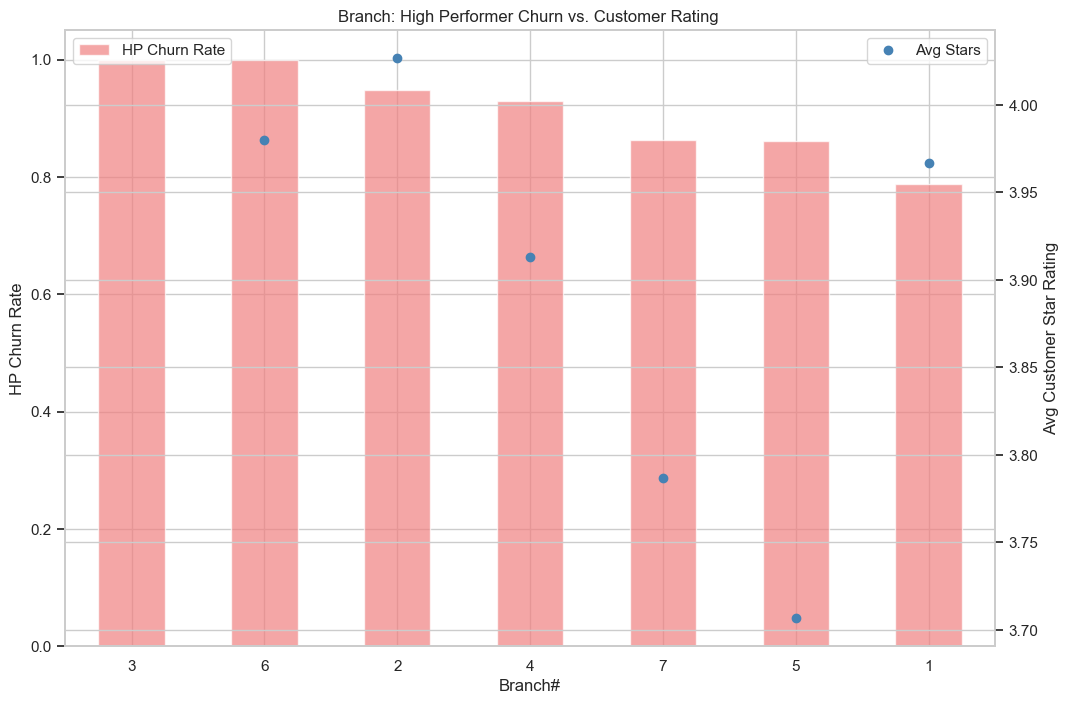

In [104]:
fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx()
branch_churn["HPChurnRate"].plot(kind="bar", ax=ax1, color="lightcoral", alpha=0.7, label="HP Churn Rate", xlabel="Branch#")
branch_churn["AvgStars"].plot(ax=ax2, color="steelblue", marker="o", label="Avg Stars", linewidth=0)
ax1.tick_params(axis='x', labelrotation=0)
ax1.set_ylabel("HP Churn Rate")
ax2.set_ylabel("Avg Customer Star Rating")
plt.title("Branch: High Performer Churn vs. Customer Rating ")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

## Section 9 - Wage vs. Performance Alignment
Answers: Is compensation progression aligned with performance progression, or do strong performers experience wage stagnation before exiting? (Guiding Q7)

### (A) - Inspect Wage Values

In [105]:
print(employee["Wage"].value_counts())
wage_order = employee["Wage"].value_counts().index.tolist()

Wage
Competitive    502
Minimum        425
Premium        140
Name: count, dtype: int64


### (B) - Wage Distribution: High Performers Who Left vs. Stayed

([0, 1, 2],
 [Text(0, 0, 'Competitive'), Text(1, 0, 'Minimum'), Text(2, 0, 'Premium')])

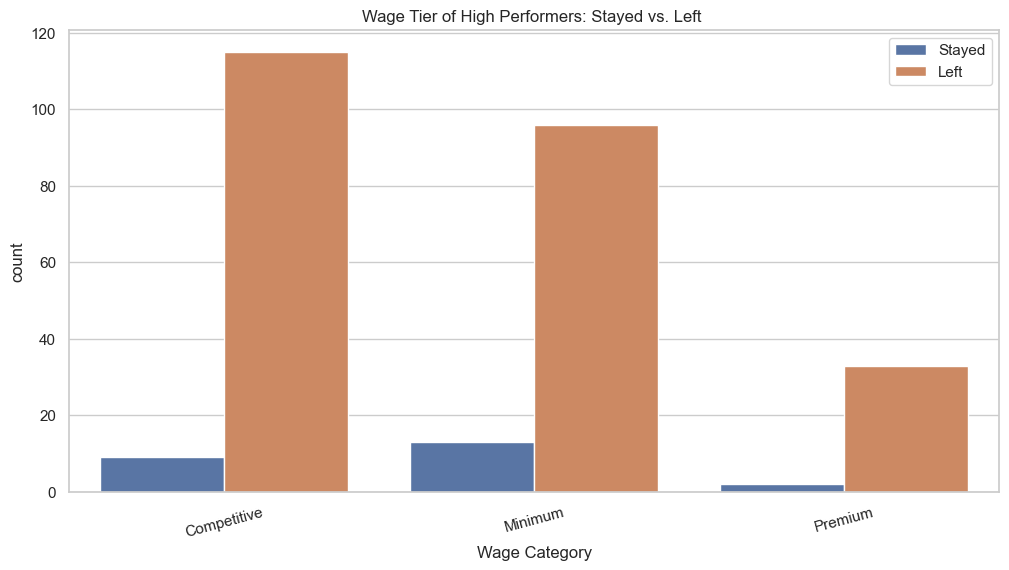

In [106]:
hp = employee[employee["IsHighPerformer"] == 1].copy()

sns.countplot(x="Wage", hue="Churned", data=hp,
              order=wage_order, palette=["#4C72B0", "#DD8452"])
plt.title("Wage Tier of High Performers: Stayed vs. Left ")
plt.xlabel("Wage Category")
plt.legend(labels=["Stayed", "Left"])
plt.xticks(rotation=15)

### (C) Performance Score Distribution by Tier

([0, 1, 2],
 [Text(0, 0, 'Competitive'), Text(1, 0, 'Minimum'), Text(2, 0, 'Premium')])

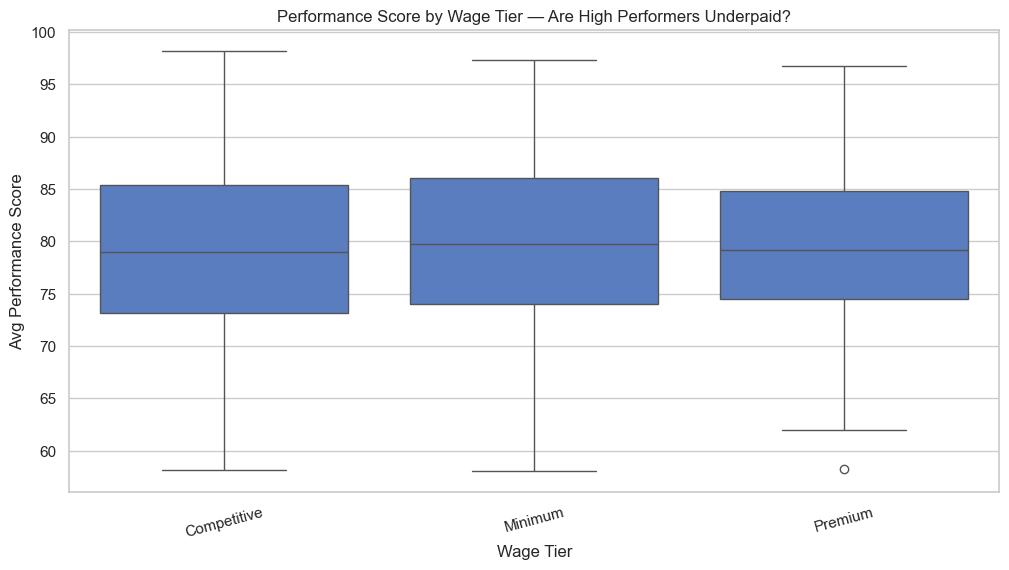

In [107]:
sns.boxplot(x="Wage", y="AvgPerfScore", data=employee, order=wage_order)
plt.title("Performance Score by Wage Tier — Are High Performers Underpaid?")
plt.xlabel("Wage Tier")
plt.ylabel("Avg Performance Score")
plt.xticks(rotation=15)

### (D) - Churn Rate by Wage Tier (High Performers Only)


(array([0, 1, 2]),
 [Text(0, 0, 'Premium'), Text(1, 0, 'Competitive'), Text(2, 0, 'Minimum')])

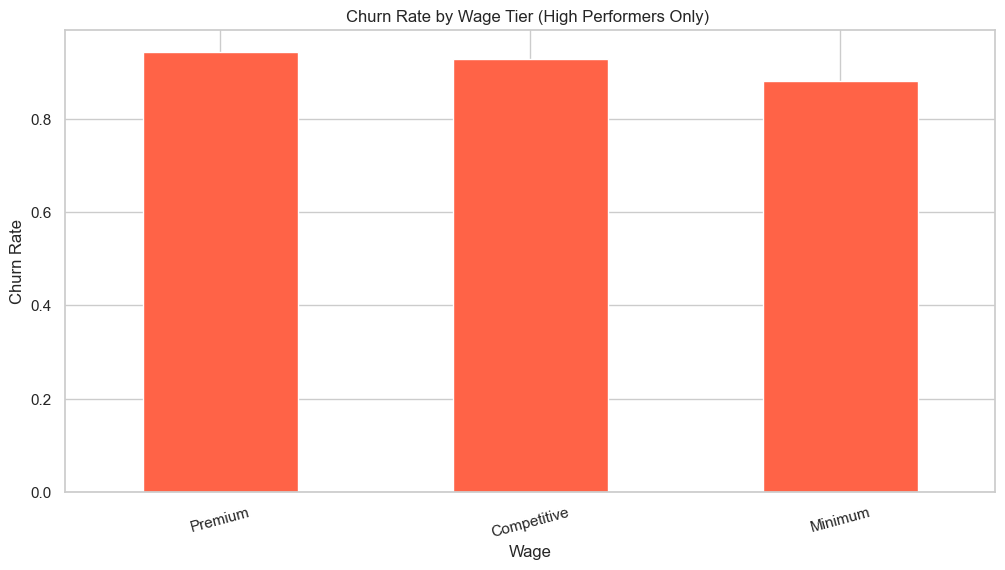

In [108]:
wage_churn = hp.groupby("Wage")["Churned"].mean().sort_values(ascending=False)
wage_churn.plot(kind="bar", color="tomato", edgecolor="white")
plt.title("Churn Rate by Wage Tier (High Performers Only) ")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)

## Section 10 - Working Hours & Exit Risk
Answers: Do working hours (e.g., part-time intensity) influence exit risk among high performers? (Guiding Q8)

### (A) Kernel Density Estimate: Weekly Hours, Left vs. Stayed (High Performers)


/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/3925043511.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(hp_left["AvgWorkingHours/Week"],   label="Left",   shade=True, color="red")
/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/3925043511.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(hp_stayed["AvgWorkingHours/Week"], label="Stayed", shade=True, color="blue")


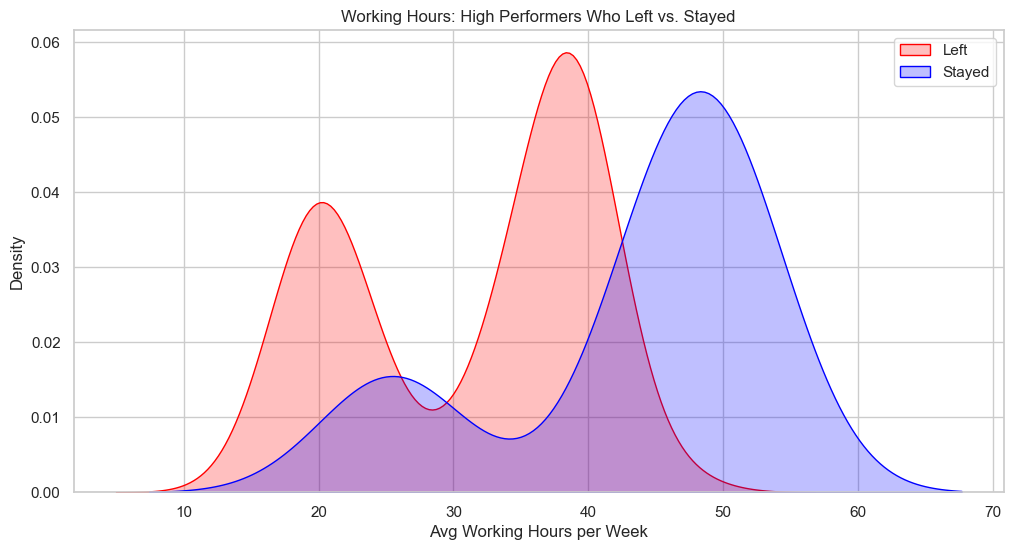

In [109]:
hp_left   = employee[(employee["IsHighPerformer"] == 1) & (employee["Churned"] == 1)]
hp_stayed = employee[(employee["IsHighPerformer"] == 1) & (employee["Churned"] == 0)]

plt.figure(figsize=(12, 6))
sns.kdeplot(hp_left["AvgWorkingHours/Week"],   label="Left",   shade=True, color="red")
sns.kdeplot(hp_stayed["AvgWorkingHours/Week"], label="Stayed", shade=True, color="blue")
plt.xlabel("Avg Working Hours per Week")
plt.title("Working Hours: High Performers Who Left vs. Stayed")
plt.legend()

### (B) Churn Rate by Hours Bucket

/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/1022259106.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("HoursBucket")["Churned"]


(array([0, 1, 2, 3]),
 [Text(0, 0, '<15 hrs'),
  Text(1, 0, '15–25 hrs'),
  Text(2, 0, '25–35 hrs'),
  Text(3, 0, '35+ hrs')])

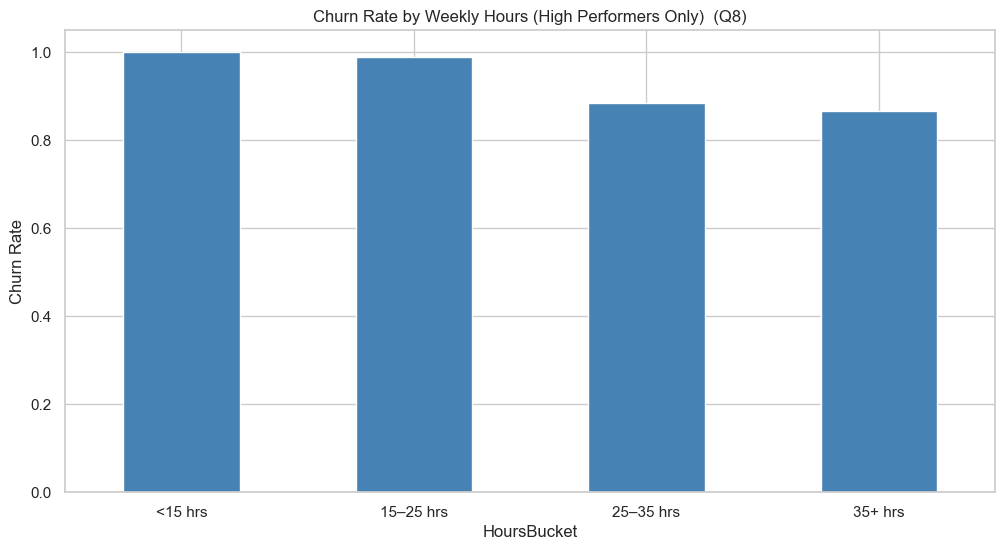

In [110]:
bins = [0, 15, 25, 35, 100]
labels = ["<15 hrs", "15–25 hrs", "25–35 hrs", "35+ hrs"]
employee["HoursBucket"] = pd.cut(employee["AvgWorkingHours/Week"], bins=bins, labels=labels)

hp_hours = (
    employee[employee["IsHighPerformer"] == 1]
    .groupby("HoursBucket")["Churned"]
    .mean()
)
hp_hours.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Churn Rate by Weekly Hours (High Performers Only)  (Q8)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)

### (C) Position Column: Does It Encode Employment Type?


In [111]:
# Position may distinguish full-time vs. part-time — directly relevant to Q8 and Q9
employee.groupby("Position")[["AvgWorkingHours/Week", "Churned"]].mean().round(2)

,AvgWorkingHours/Week,Churned
Position,,
full-time,38.51,0.85
part-time,19.53,0.92


## Section 11 - Student Status & Short-Term Intent
Answers: Does the data support managers’ assumption that turnover is primarily driven by student status and short-term career intentions? (Guiding Q9)

Context: Managers argued turnover is mainly driven by students with short-term intentions.
HighestEducationLevel from the applicant table is the best available proxy.

### (A) Churn Rate by Education Level

In [112]:
print(employee["HighestEducationLevel"].value_counts())

edu_churn = employee.groupby("HighestEducationLevel")["Churned"].mean().sort_values(ascending=False)
print(edu_churn.map("{:.1%}".format))

HighestEducationLevel
Bachelor            432
Associate Degree    276
High School         271
Master               78
PhD                  10
Name: count, dtype: int64
HighestEducationLevel
PhD                 100.0%
Bachelor             89.8%
Master               88.5%
Associate Degree     87.7%
High School          86.0%
Name: Churned, dtype: object


### (B) Countplot: Churn by Education Level

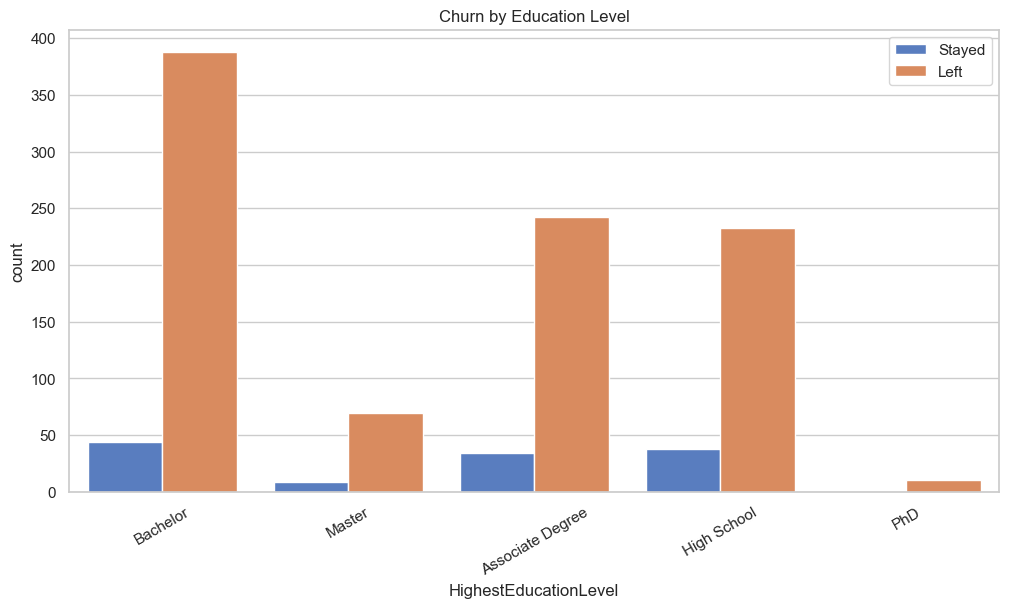

In [113]:
sns.countplot(x="HighestEducationLevel", hue="Churned", data=employee)
plt.title("Churn by Education Level")
plt.xticks(rotation=30)
plt.legend(labels=["Stayed", "Left"])

### (C) Among High Performers Only

In [114]:
hp = employee[employee["IsHighPerformer"] == 1]
hp_edu_churn = hp.groupby("HighestEducationLevel")["Churned"].mean().sort_values(ascending=False)
print(hp_edu_churn.map("{:.1%}".format))

HighestEducationLevel
Associate Degree    100.0%
PhD                 100.0%
High School          94.3%
Master               93.1%
Bachelor             88.6%
Name: Churned, dtype: object


### (D) Exit Reasons Frequency

ReasonForLeaving
Better Offer          231
Lack of Growth        169
Burntout              124
Insufficient Wages    119
Poor Management       114
Performance            85
Relocation             46
Attendance             30
Policy Violation       24
Name: count, dtype: int64


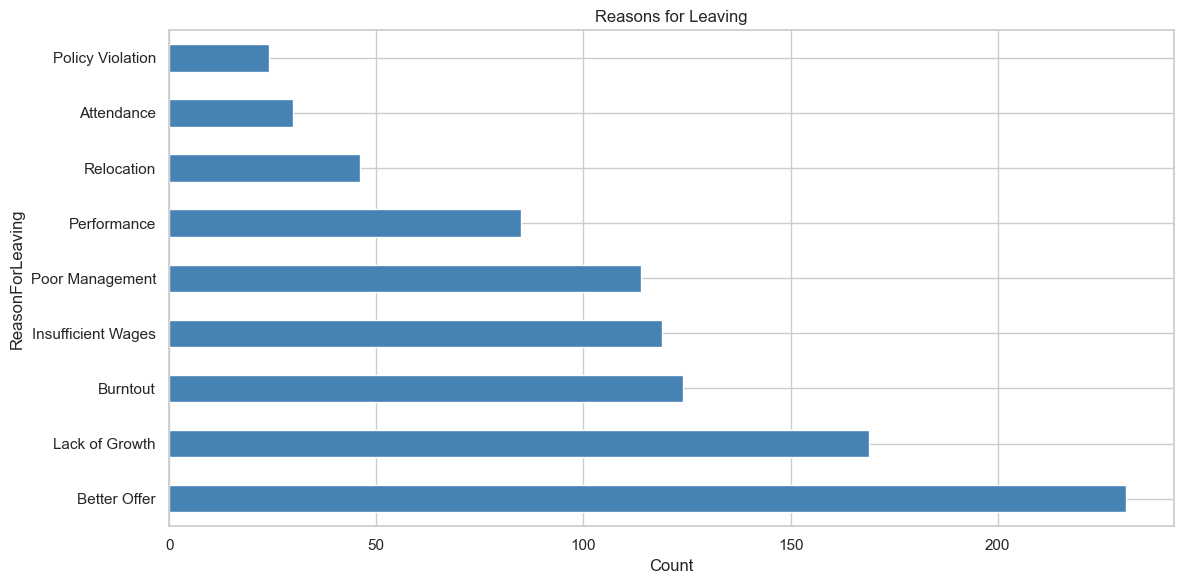

In [115]:
exit_reasons = changes[changes["isExit"] & changes["ReasonForLeaving"].notna()]

# Use value_counts() first — reasons may already be clean categorical phrases
print(exit_reasons["ReasonForLeaving"].value_counts())

exit_reasons["ReasonForLeaving"].value_counts().head(15).plot(kind="barh", color="steelblue")
plt.title("Reasons for Leaving")
plt.xlabel("Count")
plt.tight_layout()

### (E) Exit Reasons for High Performers Specifically

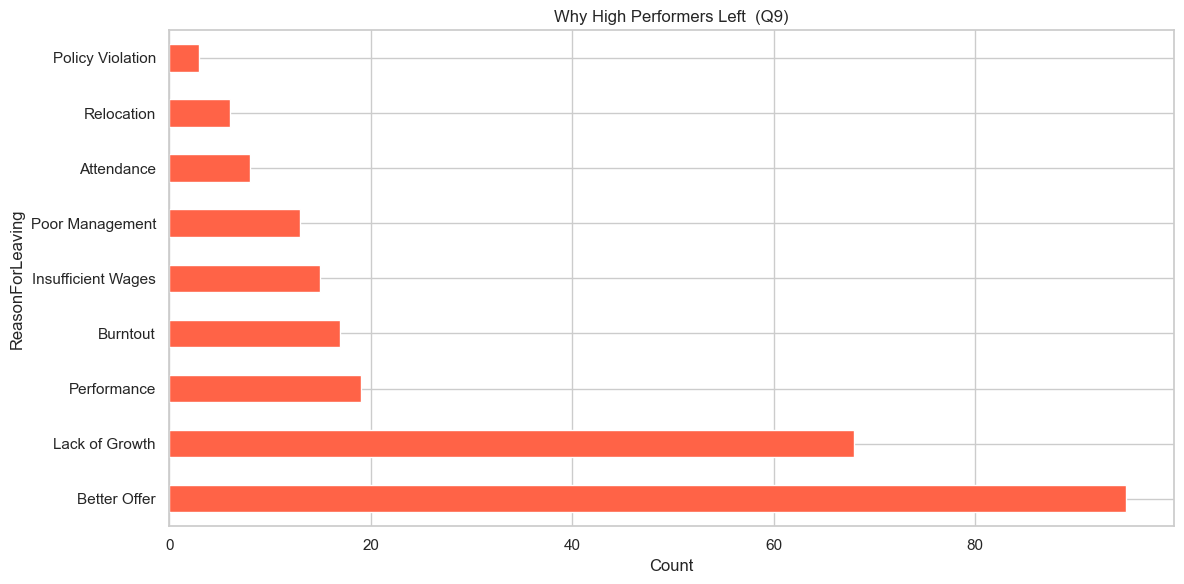

In [116]:
hp_ids  = employee[employee["IsHighPerformer"] == 1]["EmployeeID"]
hp_exits = exit_reasons[exit_reasons["EmployeeID"].isin(hp_ids)]

hp_exits["ReasonForLeaving"].value_counts().plot(kind="barh", color="tomato")
plt.title("Why High Performers Left  (Q9)")
plt.xlabel("Count")
plt.tight_layout()

### (F) Experience at Hire vs. Churn

/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/3899746031.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(employee[employee["Churned"] == 1]["YearsOfRelevantExperience"],
/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_46871/3899746031.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(employee[employee["Churned"] == 0]["YearsOfRelevantExperience"],


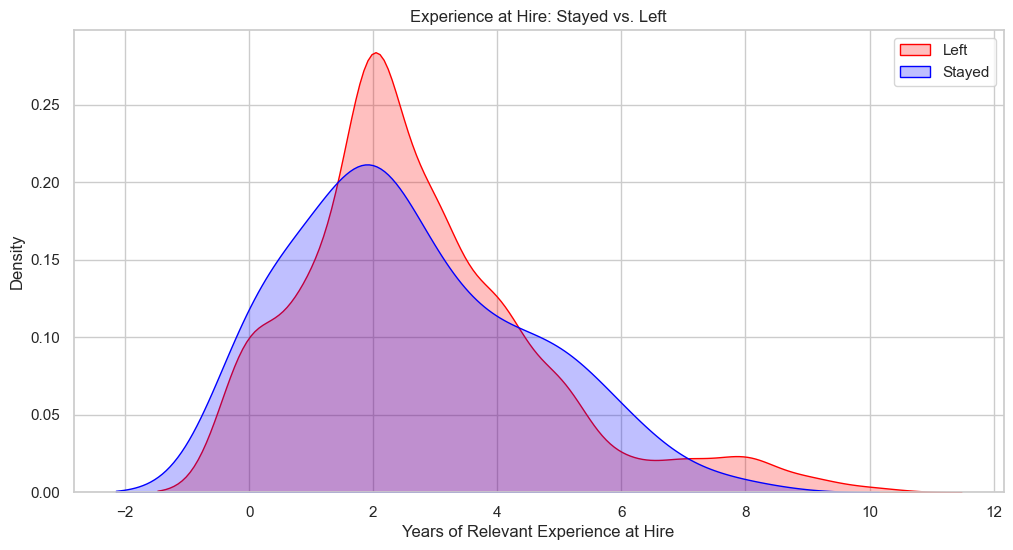

In [117]:
# YearsOfRelevantExperience — do more experienced hires stay longer?
plt.figure(figsize=(12, 6))
sns.kdeplot(employee[employee["Churned"] == 1]["YearsOfRelevantExperience"],
            label="Left",   shade=True, color="red")
sns.kdeplot(employee[employee["Churned"] == 0]["YearsOfRelevantExperience"],
            label="Stayed", shade=True, color="blue")
plt.xlabel("Years of Relevant Experience at Hire")
plt.title("Experience at Hire: Stayed vs. Left")
plt.legend()

## Section 12 - Summary Dashboard

In [118]:
employee.to_csv("employee_master.csv", index=False)

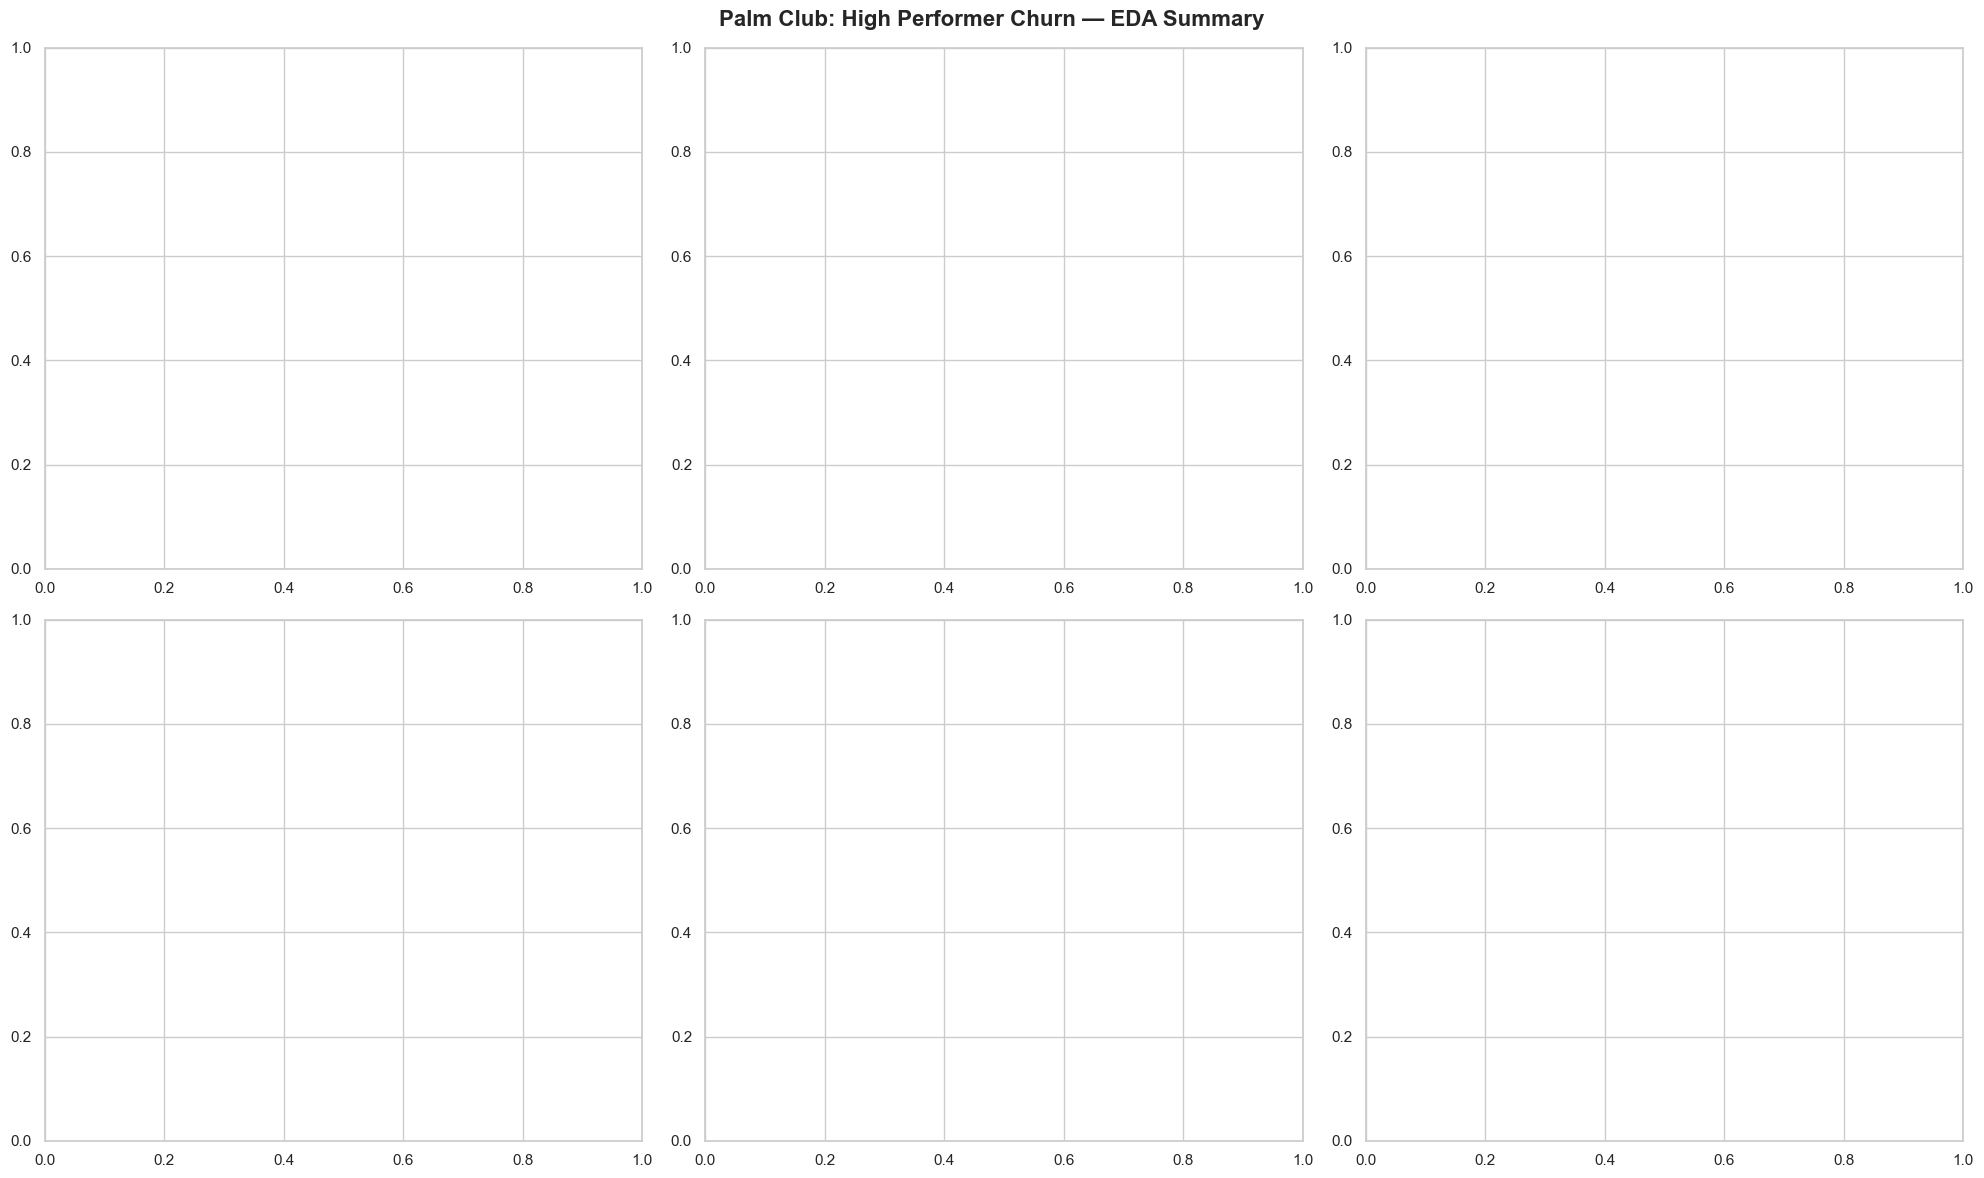

In [119]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Palm Club: High Performer Churn — EDA Summary", fontsize=16, fontweight="bold")

# Rebuild each of the 6 key charts into its axis using ax=axes[r,c]:
# [0,0] Churn rate: high performer vs. other      (Section 4b)
# [0,1] KDE: tenure at exit                       (Section 5a)
# [0,2] Months to first promotion by perf tier    (Section 6a)
# [1,0] Branch churn rate bar chart               (Section 8a)
# [1,1] Wage tier vs. churn — HP only             (Section 9d)
# [1,2] Working hours KDE                         (Section 10a)

plt.tight_layout()
plt.savefig("eda_summary_dashboard.png", dpi=150, bbox_inches="tight")